# Analysis of Grammatical Voice Effect on Wording Change Detection

This notebook analyzes experimental data to test the hypothesis that **passive sentences** lead to better encoding of surface structure, resulting in higher accuracy for detecting wording changes compared to **active sentences**.

**Hypothesis:**
> The grammatical voice of a sentence determines its storage mechanism. Because passive sentences are less common and less fluent, they act as a cognitive "speed bump" (a desirable difficulty) that forces the brain to explicitly encode the surface structure. Consequently, participants will be more accurate at detecting wording changes in passive sentences than in active sentences.

**Experimental Design:**
- **Study Phase:** Participants view sentences in either Active (_A) or Passive (_P) voice.
- **Test Phase:** Participants view the sentence again. It is either Identical (Same Voice) or Transformed (Opposite Voice).
- **Task:**
    1. Press Spacebar (IR) if they recognize the sentence content.
    2. Press Yes/No (WR) to indicate if the wording is identical or changed.
- **Key Metric:** Accuracy of the Wording Recognition (WR) response.

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visualization style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Define path to log files
log_path = 'NewLogsAnonymized'
log_pattern = os.path.join(log_path, '*.log')

# Find all log files
all_files = glob.glob(log_pattern)
print(f'Found {len(all_files)} log files.')

Found 114 log files.


In [2]:
# Load and concatenate all participant log files
df_list = []

for filename in all_files:
    try:
        df = pd.read_csv(filename, on_bad_lines='skip')
        df_list.append(df)
    except Exception as e:
        print(f'Error reading {filename}: {e}')

if df_list:
    raw_data = pd.concat(df_list, axis=0, ignore_index=True)
    print(f'Successfully loaded {len(raw_data)} rows from {len(df_list)} files.')
else:
    print('No data loaded.')
    raw_data = pd.DataFrame()

# Remove all practice events (Event starts with "Practice")
practice_mask = raw_data['Event'].str.startswith('Practice', na=False)
print(f'Removing {practice_mask.sum()} practice events.')
raw_data = raw_data[~practice_mask].reset_index(drop=True)

print(f'Rows after removing practice events: {len(raw_data)}')
print(f'Unique events: {raw_data["Event"].unique()}')
raw_data.head()

Successfully loaded 81329 rows from 114 files.
Removing 5269 practice events.
Rows after removing practice events: 76060
Unique events: ['Sentence shown' 'gap_time' 'Validation Wrong IR pressed' 'IR pressed'
 'WR pressed' 'Validation IR pressed' 'Rest Phase started'
 'Validation Missed']


,participant_ID,Timestamp,Event,Stimulus,isTarget,isValidation,isRepeat,Button,Accuracy IR,Accuracy WR,Reaction_time_IR,Reaction_time_WR,CR_IR,CR_WR
0,232,1770219378184,Sentence shown,HF_29_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,232,1770219382186,gap_time,NaN,NaN,NaN,NaN,GapTime_1289,NaN,NaN,NaN,NaN,NaN,NaN
2,232,1770219383476,Sentence shown,HF_9_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,232,1770219387478,gap_time,NaN,NaN,NaN,NaN,GapTime_1108,NaN,NaN,NaN,NaN,NaN,NaN
4,232,1770219388587,Sentence shown,HF_24_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning and Feature Engineering

We reconstruct the trial pairs (Study -> Test) to identify the **Original Voice** for each test trial.

Steps:
1. Extract the **Core ID** from the `Stimulus` column (removing the `_A` or `_P` suffix).
2. Extract the **Voice** (A or P) from the `Stimulus`.
3. Separate events into:
    - **Study Events**: `Sentence shown` where `isRepeat` is not True (first presentation).
    - **Test Events**: `WR pressed` (recognition response on repeated presentation).
4. Merge Study and Test events on `participant_ID` and `Core ID` to link the Original Voice to the Test Response.

In [3]:
# Helper function to extract Core ID and Voice from Stimulus
def parse_stimulus(stim):
    if pd.isna(stim):
        return None, None
    parts = stim.rsplit('_', 1)
    if len(parts) == 2:
        core_id = parts[0]
        voice = parts[1]  # Expected 'A' or 'P'
        return core_id, voice
    return stim, None

# Apply parsing
raw_data['Core_ID'], raw_data['Voice'] = zip(*raw_data['Stimulus'].apply(parse_stimulus))

# Convert columns to numeric
for col in ['Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR']:
    raw_data[col] = pd.to_numeric(raw_data[col], errors='coerce')

# Convert boolean-like columns
for col in ['isTarget', 'isValidation', 'isRepeat']:
    raw_data[col] = raw_data[col].astype(str).str.strip().str.lower() == 'true'

# Sort chronologically per participant
raw_data = raw_data.sort_values(['participant_ID', 'Timestamp']).reset_index(drop=True)

# ======================================================================
# Build trial-level data (matching R approach):
# Each trial starts at a "Sentence shown" event and includes all
# subsequent events until the next "Sentence shown".
# ======================================================================
raw_data['trial_id'] = raw_data.groupby('participant_ID')['Event'].transform(
    lambda x: (x == 'Sentence shown').cumsum()
)
raw_data = raw_data[raw_data['trial_id'] > 0].copy()

# Sentence-shown metadata (one row per trial)
sent_rows = raw_data[raw_data['Event'] == 'Sentence shown'].drop_duplicates(
    subset=['participant_ID', 'trial_id'], keep='first'
)[['participant_ID', 'trial_id', 'Stimulus', 'Core_ID', 'Voice',
   'isTarget', 'isValidation', 'isRepeat']].copy()

# Trial-level aggregates
trial_agg = raw_data.groupby(['participant_ID', 'trial_id']).agg(
    ir_pressed=('Event', lambda x: x.str.contains('IR pressed').any()),
    wr_pressed=('Event', lambda x: x.str.contains('WR pressed').any()),
    has_validation=('Event', lambda x: x.str.contains('Validation').any()),
    ir_accuracy=('Accuracy IR', 'max'),
    wr_accuracy=('Accuracy WR', 'max'),
    ir_rt=('Reaction_time_IR', 'min'),
    wr_rt=('Reaction_time_WR', 'min'),
).reset_index()

# Merge into trial table
trials = sent_rows.merge(trial_agg, on=['participant_ID', 'trial_id'])
trials['is_validation'] = trials['isValidation'] | trials['has_validation']
trials.rename(columns={'isTarget': 'is_target', 'isRepeat': 'is_repeat'}, inplace=True)

print(f'Built {len(trials)} trials from {trials["participant_ID"].nunique()} participants')
print(f'Validation trials: {trials["is_validation"].sum()}')
print(f'Repeat trials: {trials["is_repeat"].sum()}')

# ======================================================================
# PARTICIPANT EXCLUSION using validation trials (matching R approach):
# correct_ir > (wrong_ir / 2) + missed_ir
# ======================================================================
val_trials = trials[trials['is_validation']].copy()

validation_summary = val_trials.groupby('participant_ID').apply(
    lambda g: pd.Series({
        'correct_ir': (g['is_repeat'] & g['ir_pressed']).sum(),
        'wrong_ir':   (~g['is_repeat'] & g['ir_pressed']).sum(),
        'missed_ir':  (g['is_repeat'] & ~g['ir_pressed']).sum(),
    })
).reset_index()
validation_summary['passes'] = (
    validation_summary['correct_ir'] > (validation_summary['wrong_ir'] / 2) + validation_summary['missed_ir']
)

print('\nValidation summary per participant:')
display(validation_summary)

valid_ids = validation_summary.loc[validation_summary['passes'], 'participant_ID'].tolist()
excluded_ids = validation_summary.loc[~validation_summary['passes'], 'participant_ID'].tolist()

print(f'\nValidation check:')
print(f'  Participants excluded: {len(excluded_ids)}  {excluded_ids}')
print(f'  Participants kept:     {len(valid_ids)}')

# Keep valid participants, exclude validation trials for analysis
trials_valid = trials[(trials['participant_ID'].isin(valid_ids))].copy()

# ======================================================================
# Compute CORRECTED MEMORABILITY = Hit Rate - False Alarm Rate
# Per participant AND per Original Voice (A vs P)
#
# Hits:  from non-validation repeat trials where ir_pressed is True
# FA:    from ALL "IR pressed" events where Accuracy IR == 0
#        (these include validation trials -- the "Validation Wrong IR
#         pressed" events that the trial filter would otherwise exclude)
# ======================================================================

# Get Original Voice from first (non-repeat) presentation of each Core_ID
first_pres = trials_valid[~trials_valid['is_repeat']].drop_duplicates(
    subset=['participant_ID', 'Core_ID'], keep='first'
)[['participant_ID', 'Core_ID', 'Voice']].rename(columns={'Voice': 'Original_Voice'})

# Attach Original Voice to valid trials
trials_valid = trials_valid.merge(first_pres, on=['participant_ID', 'Core_ID'], how='left')

# Keep only trials with valid voice
voice_trials = trials_valid[trials_valid['Original_Voice'].isin(['A', 'P'])].copy()

# --- Hits: from non-validation repeat trials ---
hit_data = voice_trials.groupby(['participant_ID', 'Original_Voice']).apply(
    lambda g: pd.Series({
        'n_old': g['is_repeat'].sum(),
        'hits':  (g['is_repeat'] & g['ir_pressed']).sum(),
    })
).reset_index()
hit_data['hit_rate'] = np.where(hit_data['n_old'] > 0, hit_data['hits'] / hit_data['n_old'], np.nan)

# --- FAs: from raw IR pressed events where Accuracy IR == 0 ---
# (kept participants only)
raw_kept = raw_data[raw_data['participant_ID'].isin(valid_ids)].copy()

# All IR pressed events with Accuracy IR == 0 (false alarms)
ir_all = raw_kept[raw_kept['Event'] == 'IR pressed'].copy()
ir_all = ir_all.merge(first_pres, on=['participant_ID', 'Core_ID'], how='left')

# All first-presentation (non-repeat) sentence shown events (FA denominator)
first_shown = raw_kept[
    (raw_kept['Event'] == 'Sentence shown') &
    (~raw_kept['isRepeat'])
].copy()
first_shown = first_shown.merge(first_pres, on=['participant_ID', 'Core_ID'], how='left')

fa_data = []
for pid in valid_ids:
    for voice in ['A', 'P']:
        fa_count = len(ir_all[
            (ir_all['participant_ID'] == pid) &
            (ir_all['Original_Voice'] == voice) &
            (ir_all['Accuracy IR'] == 0)
        ])
        nontarget = len(first_shown[
            (first_shown['participant_ID'] == pid) &
            (first_shown['Original_Voice'] == voice)
        ])
        fa_rate = fa_count / nontarget if nontarget > 0 else np.nan
        fa_data.append({
            'participant_ID': pid,
            'Original_Voice': voice,
            'false_alarms': fa_count,
            'n_new': nontarget,
            'fa_rate': fa_rate,
        })
fa_df = pd.DataFrame(fa_data)


# Merge hits and FAs
mem_df = hit_data.merge(fa_df, on=['participant_ID', 'Original_Voice'], how='outer')
mem_df['corrected_memorability'] = mem_df['hit_rate'] - mem_df['fa_rate']

print('\n=== Corrected Memorability (Hit Rate - FA Rate) per participant x voice ===')
for v in ['A', 'P']:
    sub = mem_df[mem_df['Original_Voice'] == v]
    print(f'\nVoice {v}:')
    print(f'  Mean Hit Rate:    {sub["hit_rate"].mean():.4f}')
    print(f'  Mean FA Rate:     {sub["fa_rate"].mean():.4f}')
    print(f'  Mean Corrected M: {sub["corrected_memorability"].mean():.4f}')
display(mem_df.groupby('Original_Voice')[['hit_rate', 'fa_rate', 'corrected_memorability']].describe())

# ======================================================================
# Build analysis_df for WR accuracy analysis
# ======================================================================

# Study Events: First presentation (non-repeat)
study_df = trials_valid[~trials_valid['is_repeat']].drop_duplicates(
    subset=['participant_ID', 'Core_ID'], keep='first'
)[['participant_ID', 'Core_ID', 'Voice']].copy()
study_df.rename(columns={'Voice': 'Original_Voice'}, inplace=True)

# Test Events: Repeat trials where WR was pressed
test_df = trials_valid[trials_valid['is_repeat'] & trials_valid['wr_pressed']].drop_duplicates(
    subset=['participant_ID', 'Core_ID'], keep='first'
)[['participant_ID', 'Core_ID', 'Voice', 'wr_accuracy', 'wr_rt']].copy()
test_df.rename(columns={
    'Voice': 'Test_Voice',
    'wr_accuracy': 'Accuracy WR',
    'wr_rt': 'Reaction_time_WR'
}, inplace=True)

# Merge Study and Test
analysis_df = pd.merge(test_df, study_df, on=['participant_ID', 'Core_ID'], how='inner')

# Determine if the test was Identical or Transformed
analysis_df['Condition'] = np.where(
    analysis_df['Original_Voice'] == analysis_df['Test_Voice'], 'Identical', 'Transformed'
)

# Keep only valid voice values
analysis_df = analysis_df[analysis_df['Original_Voice'].isin(['A', 'P'])].copy()

# Merge corrected memorability
analysis_df = analysis_df.merge(
    mem_df[['participant_ID', 'Original_Voice', 'corrected_memorability', 'hit_rate', 'fa_rate']],
    on=['participant_ID', 'Original_Voice'], how='left'
)

print(f'\nTotal matched test trials: {len(analysis_df)}')
print(f'Unique participants: {analysis_df["participant_ID"].nunique()}')
print(f'\nOriginal Voice counts:\n{analysis_df["Original_Voice"].value_counts()}')
print(f'\nCondition counts:\n{analysis_df["Condition"].value_counts()}')
analysis_df.head()

Built 25308 trials from 114 participants
Validation trials: 5502
Repeat trials: 8892

Validation summary per participant:


C:\Users\ASUS\AppData\Local\Temp\ipykernel_46452\2772068382.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  validation_summary = val_trials.groupby('participant_ID').apply(


,participant_ID,correct_ir,wrong_ir,missed_ir,passes
0,232,30,16,0,True
1,235,29,22,1,True
2,236,30,15,0,True
3,241,29,24,1,True
4,242,27,3,3,True
...,...,...,...,...,...
109,392,29,26,1,True
110,395,28,13,2,True
111,396,30,6,0,True
112,397,30,6,0,True



Validation check:
  Participants excluded: 2  [271, 299]
  Participants kept:     112


C:\Users\ASUS\AppData\Local\Temp\ipykernel_46452\2772068382.py:114: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hit_data = voice_trials.groupby(['participant_ID', 'Original_Voice']).apply(



=== Corrected Memorability (Hit Rate - FA Rate) per participant x voice ===

Voice A:
  Mean Hit Rate:    0.8937
  Mean FA Rate:     0.1390
  Mean Corrected M: 0.7547

Voice P:
  Mean Hit Rate:    0.8411
  Mean FA Rate:     0.0450
  Mean Corrected M: 0.7961


hit_rate                                                    \
                  count      mean       std       min       25%       50%   
Original_Voice                                                              
A                 112.0  0.893684  0.099049  0.444444  0.851852  0.907407   
P                 112.0  0.841146  0.148138  0.250000  0.791667  0.875000   

                              fa_rate            ...                      \
                     75%  max   count      mean  ...       75%       max   
Original_Voice                                   ...                       
A               0.962963  1.0   112.0  0.138988  ...  0.183333  0.391667   
P               0.958333  1.0   112.0  0.045015  ...  0.083333  0.208333   

               corrected_memorability                                          \
                                count      mean       std       min       25%   
Original_Voice                                                                  
A                               112.0  0.754696  0.115382  0.402778  0.666898   
P                               112.0  0.796131  0.147908  0.250000  0.708333   

                                              
                     50%       75%       max  
Original_Voice                                
A               0.775000  0.842824  0.939815  
P               0.833333  0.916667  1.000000  

[2 rows x 24 columns]


Total matched test trials: 7666
Unique participants: 112

Original Voice counts:
Original_Voice
A    5405
P    2261
Name: count, dtype: int64

Condition counts:
Condition
Identical      5489
Transformed    2177
Name: count, dtype: int64


,participant_ID,Core_ID,Test_Voice,Accuracy WR,Reaction_time_WR,Original_Voice,Condition,corrected_memorability,hit_rate,fa_rate
0,232,HF_31,A,NaN,740.0,A,Identical,0.866667,1.000000,0.133333
1,232,HF_12,A,NaN,753.0,A,Identical,0.866667,1.000000,0.133333
2,232,LVL_148,A,1.0,1410.0,P,Transformed,0.958333,0.958333,0.000000
3,232,HF_17,A,NaN,743.0,A,Identical,0.866667,1.000000,0.133333
4,232,HVL_121,P,1.0,544.0,P,Identical,0.958333,0.958333,0.000000


---
## Shared Data Preparation for H1 & H2

Corrected memorability computed per **participant × lexical condition × voice** cell, then averaged appropriately for each hypothesis.

- `mem_h1` — averaged over voice → one score per participant × lexical condition (for H1)
- `mem_h2` — averaged over lexical condition → one score per participant × voice (for H2)

In [4]:
import re

# ── Map stimulus code → lexical condition label ──────────────────────
def get_condition(core_id):
    if pd.isna(core_id):
        return 'Other'
    m = re.match(r'^([A-Za-z]+)', str(core_id))
    if m:
        c = m.group(1).upper()
        return {'HH': 'HH', 'HVL': 'HL', 'LVH': 'LH', 'LVL': 'LL', 'HF': 'Filler'}.get(c, 'Other')
    return 'Other'

trials_valid['label_group'] = trials_valid['Core_ID'].apply(get_condition)

# ── Corrected memorability per participant × condition × voice ────────
# Matches R's sentence_memorability:  CM = Hit Rate − False Alarm Rate
#   Hits:         repeat trials where IR was pressed
#   False Alarms: non-repeat trials where IR was pressed
target = trials_valid[
    ~trials_valid['is_validation'] &
    trials_valid['label_group'].isin(['HH', 'HL', 'LH', 'LL']) &
    trials_valid['Voice'].isin(['A', 'P'])
].copy()

sentence_mem = (
    target
    .groupby(['participant_ID', 'label_group', 'Voice'])
    .apply(lambda g: pd.Series({
        'n_old':        g['is_repeat'].sum(),
        'n_new':        (~g['is_repeat']).sum(),
        'hits':         (g['is_repeat'] & g['ir_pressed']).sum(),
        'false_alarms': (~g['is_repeat'] & g['ir_pressed']).sum(),
    }))
    .reset_index()
)
sentence_mem['hit_rate'] = np.where(
    sentence_mem['n_old'] > 0,
    sentence_mem['hits'] / sentence_mem['n_old'], np.nan
)
sentence_mem['false_alarm_rate'] = np.where(
    sentence_mem['n_new'] > 0,
    sentence_mem['false_alarms'] / sentence_mem['n_new'], np.nan
)
sentence_mem['corrected_memorability'] = (
    sentence_mem['hit_rate'] - sentence_mem['false_alarm_rate']
)

# H1: average over voice  → one score per participant × lexical condition
mem_h1 = (
    sentence_mem
    .groupby(['participant_ID', 'label_group'])['corrected_memorability']
    .mean()
    .reset_index()
)

# H2: average over condition → one score per participant × voice
mem_h2 = (
    sentence_mem
    .groupby(['participant_ID', 'Voice'])['corrected_memorability']
    .mean()
    .reset_index()
)

print(f"sentence_mem: {sentence_mem.shape[0]} rows  |  "
      f"mem_h1: {mem_h1.shape[0]} rows  |  mem_h2: {mem_h2.shape[0]} rows")
display(mem_h1.groupby('label_group')['corrected_memorability'].describe().round(3))
display(mem_h2.groupby('Voice')['corrected_memorability'].describe().round(3))

sentence_mem: 896 rows  |  mem_h1: 448 rows  |  mem_h2: 224 rows


C:\Users\ASUS\AppData\Local\Temp\ipykernel_46452\1345857605.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,count,mean,std,min,25%,50%,75%,max
label_group,,,,,,,,
HH,112.0,0.850,0.163,0.333,0.750,0.917,1.000,1.0
HL,112.0,0.852,0.165,0.167,0.750,0.917,1.000,1.0
LH,112.0,0.836,0.175,0.083,0.750,0.917,0.938,1.0
LL,112.0,0.794,0.183,0.083,0.667,0.833,0.917,1.0


,count,mean,std,min,25%,50%,75%,max
Voice,,,,,,,,
A,112.0,0.827,0.151,0.208,0.75,0.875,0.958,1.0
P,112.0,0.839,0.160,0.167,0.75,0.875,0.958,1.0


---
## Hypothesis 1: Lexical Condition Affects Memorability

**H₀:** Corrected memorability does *not* differ across lexical conditions (HH, HL, LH, LL).  
**H₁:** Corrected memorability differs across *at least two* of the four lexical groups.

- **DV:** Corrected memorability averaged over voice per participant × lexical condition  
- **IV:** Lexical condition — HH (high/high), HL (high/low), LH (low/high), LL (low/low)  
- **Test:** Kruskal-Wallis (non-parametric one-way); pairwise Wilcoxon + Bonferroni if significant

=== H1 Descriptive Statistics ===


,label_group,N,Mean,Median,SD,Min,Max
0,HH,112,0.850,0.917,0.163,0.333,1.0
1,HL,112,0.852,0.917,0.165,0.167,1.0
2,LH,112,0.836,0.917,0.175,0.083,1.0
3,LL,112,0.794,0.833,0.183,0.083,1.0



=== Shapiro-Wilk Normality Test (H1) ===


,Condition,W,p-value,Normal
0,HH,0.8367,< 0.001,No
1,HL,0.8122,< 0.001,No
2,LH,0.8162,< 0.001,No
3,LL,0.8849,< 0.001,No


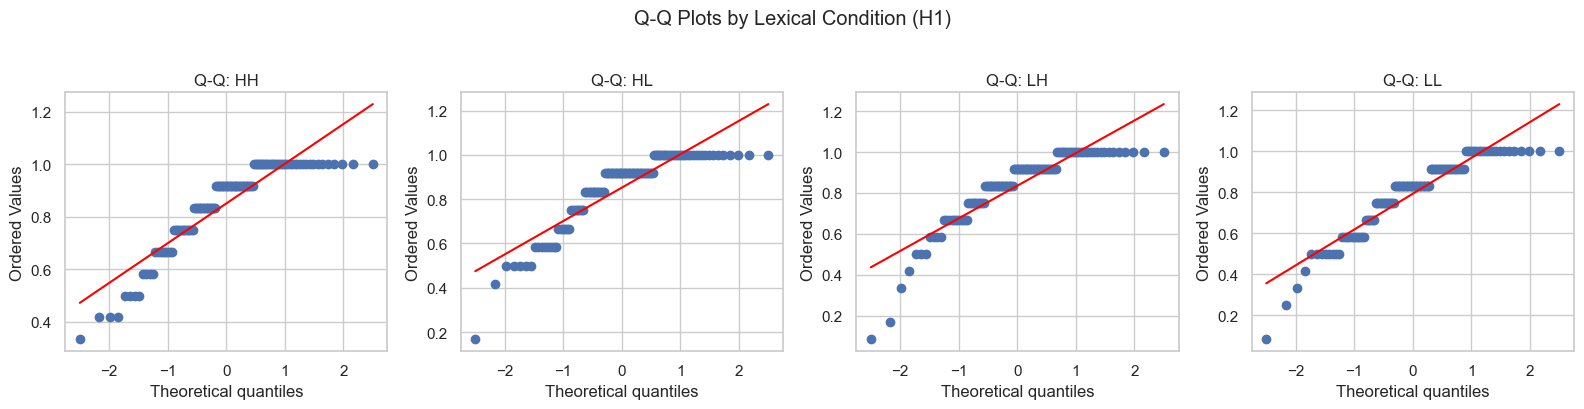

C:\Users\ASUS\AppData\Local\Temp\ipykernel_46452\3682323535.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=mem_h1, x='label_group', y='corrected_memorability',


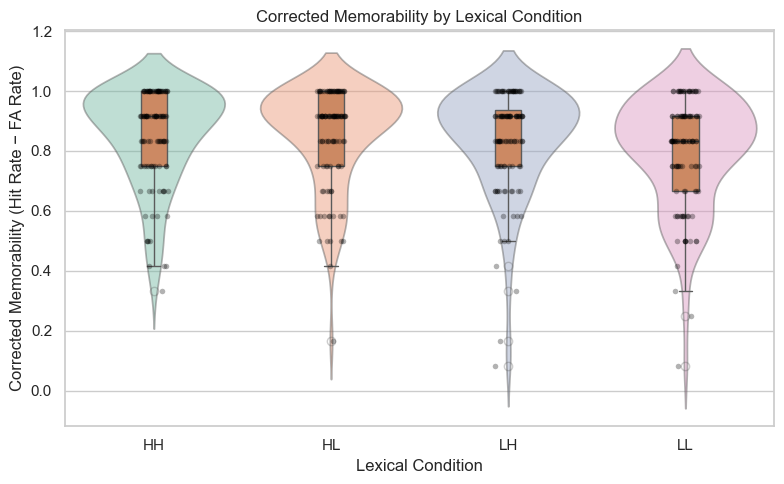


=== Kruskal-Wallis Test (H1) ===
H(3) = 10.704,  p = 0.0134
Decision: Reject H0 — H1 supported

=== Post-hoc Pairwise Wilcoxon (Bonferroni corrected) ===


,Pair,p (raw),p (Bonferroni),Significant
0,HH vs HL,0.9645,1.0000,No
1,HH vs LH,0.4352,1.0000,No
2,HH vs LL,0.0072,0.0432,Yes *
3,HL vs LH,0.3855,1.0000,No
4,HL vs LL,0.0043,0.0258,Yes *
5,LH vs LL,0.0342,0.2049,No


Significant pairs: ['HH vs LL', 'HL vs LL']


In [5]:
from itertools import combinations
from scipy.stats import kruskal, shapiro, mannwhitneyu, probplot

COND_ORDER = ['HH', 'HL', 'LH', 'LL']

# ── Descriptive statistics ────────────────────────────────────────────
h1_desc = (
    mem_h1.groupby('label_group')['corrected_memorability']
    .agg(N='count', Mean='mean', Median='median', SD='std', Min='min', Max='max')
    .reindex(COND_ORDER)
    .round(3)
    .reset_index()
)
print("=== H1 Descriptive Statistics ===")
display(h1_desc)

# ── Shapiro-Wilk normality test ────────────────────────────────────────
sw_h1 = []
for cond, grp in mem_h1.groupby('label_group'):
    w, p = shapiro(grp['corrected_memorability'].dropna())
    sw_h1.append({'Condition': cond, 'W': round(w, 4),
                  'p-value': '< 0.001' if p < 0.001 else round(p, 4),
                  'Normal': 'Yes' if p > 0.05 else 'No'})
print("\n=== Shapiro-Wilk Normality Test (H1) ===")
display(pd.DataFrame(sw_h1))

# ── Q-Q plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, cond in zip(axes, COND_ORDER):
    data = mem_h1[mem_h1['label_group'] == cond]['corrected_memorability'].dropna()
    probplot(data, dist='norm', plot=ax)
    ax.set_title(f'Q-Q: {cond}')
    ax.get_lines()[1].set_color('red')
plt.suptitle('Q-Q Plots by Lexical Condition (H1)', y=1.02)
plt.tight_layout()
plt.show()

# ── Violin + Box plot ──────────────────────────────────────────────────
palette = dict(zip(COND_ORDER, sns.color_palette('Set2', 4)))
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=mem_h1, x='label_group', y='corrected_memorability',
               order=COND_ORDER, palette=palette, inner=None, alpha=0.45, ax=ax)
sns.boxplot(data=mem_h1, x='label_group', y='corrected_memorability',
            order=COND_ORDER, width=0.15, flierprops={'alpha': 0.3},
            boxprops={'zorder': 2}, ax=ax)
sns.stripplot(data=mem_h1, x='label_group', y='corrected_memorability',
              order=COND_ORDER, jitter=0.08, alpha=0.3, size=4,
              color='black', ax=ax)
ax.set_title('Corrected Memorability by Lexical Condition')
ax.set_xlabel('Lexical Condition')
ax.set_ylabel('Corrected Memorability (Hit Rate − FA Rate)')
plt.tight_layout()
plt.show()

# ── Kruskal-Wallis test ────────────────────────────────────────────────
groups_h1 = [
    mem_h1[mem_h1['label_group'] == c]['corrected_memorability'].dropna().values
    for c in COND_ORDER
]
kw_stat, kw_p = kruskal(*groups_h1)
print(f"\n=== Kruskal-Wallis Test (H1) ===")
print(f"H({len(COND_ORDER) - 1}) = {kw_stat:.3f},  p = {kw_p:.4f}")
print(f"Decision: {'Reject H0 — H1 supported' if kw_p < 0.05 else 'Retain H0'}")

# ── Post-hoc: pairwise Wilcoxon with Bonferroni correction ────────────
if kw_p < 0.05:
    pairs = list(combinations(COND_ORDER, 2))
    raw_ps = []
    for c1, c2 in pairs:
        x1 = mem_h1[mem_h1['label_group'] == c1]['corrected_memorability'].dropna()
        x2 = mem_h1[mem_h1['label_group'] == c2]['corrected_memorability'].dropna()
        _, p = mannwhitneyu(x1, x2, alternative='two-sided')
        raw_ps.append(p)
    bonf_ps = [min(p * len(pairs), 1.0) for p in raw_ps]
    posthoc_df = pd.DataFrame({
        'Pair':          [f'{c1} vs {c2}' for c1, c2 in pairs],
        'p (raw)':       [round(p, 4) for p in raw_ps],
        'p (Bonferroni)':[round(p, 4) for p in bonf_ps],
        'Significant':   ['Yes *' if p < 0.05 else 'No' for p in bonf_ps],
    })
    print("\n=== Post-hoc Pairwise Wilcoxon (Bonferroni corrected) ===")
    display(posthoc_df)
    sig_pairs = posthoc_df[posthoc_df['Significant'] == 'Yes *']['Pair'].tolist()
    print(f"Significant pairs: {sig_pairs if sig_pairs else 'none after correction'}")
else:
    print(f"\nKruskal-Wallis not significant (p = {kw_p:.4f}) — no post-hoc comparisons.")

---
## Hypothesis 2: Voice Condition Affects Memorability

**H₀:** Corrected memorability does *not* differ between Active and Passive sentences.  
**H₁:** Active and Passive sentences *do* differ in corrected memorability.

- **DV:** Corrected memorability averaged over lexical condition per participant × voice  
- **IV:** Sentence voice — Active (`A`) vs Passive (`P`)
- **Design note:** This is **within-subjects** — each participant contributes one Active score and one Passive score.  
- **Normality check:** Shapiro-Wilk is applied to the **pairwise differences** (Active − Passive per participant), which is the correct assumption to check for a paired test.  
- **Test:** Wilcoxon **signed-rank** test — the non-parametric paired alternative to a paired t-test. Mann-Whitney U is incorrect here because it assumes independent groups.

=== H2 Descriptive Statistics ===


,Voice,N,Mean,Median,SD,Min,Max
0,Active,112,0.827,0.875,0.151,0.208,1.0
1,Passive,112,0.839,0.875,0.160,0.167,1.0



Paired participants (both voices present): 112
Mean difference (A − P): -0.0112

=== Shapiro-Wilk Normality Test on Paired Differences (H2) ===


,What was tested,W,p-value,Normal,Test justified
0,Paired differences (A − P),0.9639,0.0041,No,Wilcoxon signed-rank (non-parametric)


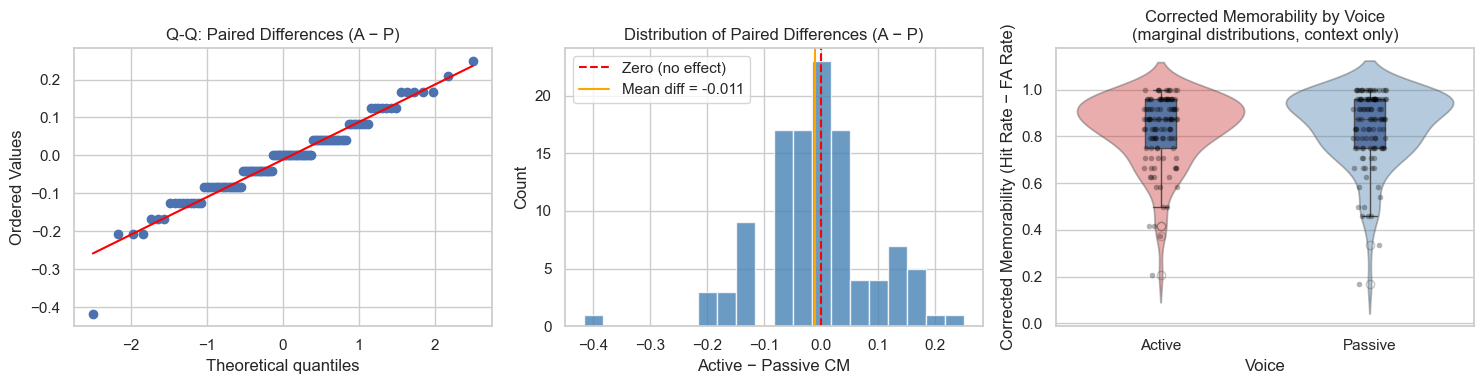


=== Wilcoxon Signed-Rank Test (paired, H2) ===
W = 1819.500,  p = 0.2776
Decision: Retain H0
→ No statistically significant paired difference in corrected memorability between Active and Passive sentences (H0 retained).


In [6]:
from scipy.stats import wilcoxon

VOICE_ORDER = ['A', 'P']
VOICE_LABELS = {'A': 'Active', 'P': 'Passive'}

# ── Descriptive statistics ─────────────────────────────────────────────
h2_desc = (
    mem_h2.groupby('Voice')['corrected_memorability']
    .agg(N='count', Mean='mean', Median='median', SD='std', Min='min', Max='max')
    .reindex(VOICE_ORDER)
    .round(3)
    .reset_index()
)
h2_desc['Voice'] = h2_desc['Voice'].map(VOICE_LABELS)
print("=== H2 Descriptive Statistics ===")
display(h2_desc)

# ── Pivot to wide format: one row per participant, columns = A and P ───
h2_wide = mem_h2.pivot(index='participant_ID', columns='Voice', values='corrected_memorability').dropna()
h2_wide.columns.name = None
h2_wide['diff'] = h2_wide['A'] - h2_wide['P']   # Active − Passive per participant
print(f"\nPaired participants (both voices present): {len(h2_wide)}")
print(f"Mean difference (A − P): {h2_wide['diff'].mean():.4f}")

# ── Shapiro-Wilk on the PAIRWISE DIFFERENCES ──────────────────────────
# Correct check: paired test assumes normality of differences, not of marginals
w_sw, p_sw = shapiro(h2_wide['diff'])
sw_h2 = pd.DataFrame([{
    'What was tested':  'Paired differences (A − P)',
    'W':                round(w_sw, 4),
    'p-value':          '< 0.001' if p_sw < 0.001 else round(p_sw, 4),
    'Normal':           'Yes' if p_sw > 0.05 else 'No',
    'Test justified':   'Wilcoxon signed-rank (non-parametric)' if p_sw <= 0.05 else 'Paired t-test (parametric)'
}])
print("\n=== Shapiro-Wilk Normality Test on Paired Differences (H2) ===")
display(sw_h2)

# ── Q-Q plot of differences ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: Q-Q of differences
probplot(h2_wide['diff'], dist='norm', plot=axes[0])
axes[0].set_title('Q-Q: Paired Differences (A − P)')
axes[0].get_lines()[1].set_color('red')

# Middle: histogram of differences with zero line
axes[1].hist(h2_wide['diff'], bins=20, edgecolor='white', color='steelblue', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero (no effect)')
axes[1].axvline(h2_wide['diff'].mean(), color='orange', linestyle='-', linewidth=1.5,
                label=f"Mean diff = {h2_wide['diff'].mean():.3f}")
axes[1].set_title('Distribution of Paired Differences (A − P)')
axes[1].set_xlabel('Active − Passive CM')
axes[1].set_ylabel('Count')
axes[1].legend()

# Right: violin + box of marginal distributions (for context only)
mem_h2_plot = mem_h2.copy()
mem_h2_plot['Voice_label'] = mem_h2_plot['Voice'].map(VOICE_LABELS)
sns.violinplot(data=mem_h2_plot, x='Voice_label', y='corrected_memorability',
               order=['Active', 'Passive'], hue='Voice_label', palette='Set1',
               legend=False, inner=None, alpha=0.4, ax=axes[2])
sns.boxplot(data=mem_h2_plot, x='Voice_label', y='corrected_memorability',
            order=['Active', 'Passive'], width=0.15, flierprops={'alpha': 0.3},
            boxprops={'zorder': 2}, ax=axes[2])
sns.stripplot(data=mem_h2_plot, x='Voice_label', y='corrected_memorability',
              order=['Active', 'Passive'], jitter=0.08, alpha=0.3, size=4,
              color='black', ax=axes[2])
axes[2].set_title('Corrected Memorability by Voice\n(marginal distributions, context only)')
axes[2].set_xlabel('Voice')
axes[2].set_ylabel('Corrected Memorability (Hit Rate − FA Rate)')

plt.tight_layout()
plt.show()

# ── Wilcoxon SIGNED-RANK test (paired / within-subjects) ──────────────
# Differences are non-normal → use Wilcoxon signed-rank (not Mann-Whitney U)
w_stat, w_p = wilcoxon(h2_wide['A'], h2_wide['P'], alternative='two-sided')
decision = 'Reject H0 — H1 supported' if w_p < 0.05 else 'Retain H0'
print(f"\n=== Wilcoxon Signed-Rank Test (paired, H2) ===")
print(f"W = {w_stat:.3f},  p = {w_p:.4f}")
print(f"Decision: {decision}")
if w_p >= 0.05:
    print("→ No statistically significant paired difference in corrected memorability "
          "between Active and Passive sentences (H0 retained).")